# AlphaFold et Drug Discovery
## De la séquence protéique à l'analyse de confiance structurale

---

### Le problème

**p53** est l'une des protéines les plus importantes en cancérologie.
Mutée dans plus de 50% des cancers humains, elle joue normalement le rôle de
suppresseur de tumeur — elle détecte les dommages à l'ADN et déclenche la mort
cellulaire avant qu'une cellule ne devienne cancéreuse.
Restaurer la fonction de p53 est donc une stratégie thérapeutique majeure.

Mais concevoir un médicament ciblant p53 nécessite de connaître sa **structure 3D**
à résolution atomique. Sans elle, impossible d'identifier les poches de liaison,
de prédire quelles molécules s'y fixeront, ou d'expliquer pourquoi un composé fonctionne.

Pendant des décennies, p53 a résisté à la caractérisation structurale — son domaine
N-terminal est intrinsèquement désordonné, ce qui rend la cristallographie quasi impossible.

**AlphaFold a changé la donne.**

À partir d'une simple séquence d'acides aminés, AlphaFold prédit la structure 3D
qu'adoptera la protéine — accompagnée d'un score de confiance par résidu (pLDDT)
qui indique *quelles régions sont fiables* pour la conception de médicaments.

---

### Objectif de ce notebook

On dissèque le pipeline de prédiction d'AlphaFold sur deux protéines :
- **p53** (P04637) — partiellement désordonnée, cible majeure en oncologie
- **Lysozyme** (P61626) — compact et bien ordonné, utilisé comme référence

On procède en trois étapes :

1. **Comment AlphaFold représente les séquences** — via ESM2, le transformer
   au cœur des modèles de langage protéiques, pour visualiser ce que le modèle apprend
2. **Ce qu'AlphaFold prédit** — structure 3D et scores pLDDT
   depuis la base de données AlphaFold
3. **Ce que cela implique pour le drug discovery** — identifier les régions
   fiables pour la liaison vs les segments désordonnés qui se comportent
   différemment comme cibles thérapeutiques


## Mise en place — Bibliothèques et modèles

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import torch
import esm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import py3Dmol
from IPython.display import display
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")
print(f"PyTorch : {torch.__version__}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

# ESM2 650M paramètres — le transformer de langage protéique
# C'est le trunk sous-jacent d'ESMFold, utilisé ici directement
# pour accéder aux représentations internes du modèle
print("\nChargement d'ESM2...")
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
model = model.eval().to(device)
batch_converter = alphabet.get_batch_converter()
print("ESM2 chargé.")

Device  : cuda
PyTorch : 2.11.0+cu130
GPU     : NVIDIA L4

Chargement d'ESM2...
ESM2 chargé.


---
## Section 1 — Préparation des séquences

On récupère les séquences canoniques depuis l'**API UniProt** —
la même source utilisée par DeepMind pour alimenter la base AlphaFold DB.

Nos deux protéines sont choisies car elles représentent deux extrêmes structuraux :
- **p53** : partiellement désordonnée, structure complexe, cible thérapeutique difficile
- **Lysozyme** : protéine modèle compacte, structure bien définie, utilisée comme référence

In [2]:
def fetch_uniprot_sequence(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    lines = r.text.strip().split("\n")
    return "".join(lines[1:])  # retirer l'en-tête FASTA

PROTEINS = {
    "p53": {
        "id": "P04637",
        "name": "Suppresseur de tumeur p53",
        "description": "Cible majeure en oncologie — domaine N-terminal intrinsèquement désordonné"
    },
    "lysozyme": {
        "id": "P61626",
        "name": "Lysozyme humain",
        "description": "Protéine globulaire compacte — structure rigide, pLDDT élevé attendu"
    },
}

print("Récupération des séquences depuis UniProt...\n")
for key, info in PROTEINS.items():
    info["sequence"] = fetch_uniprot_sequence(info["id"])
    seq = info["sequence"]
    print(f"{info['name']} ({info['id']})")
    print(f"  Longueur    : {len(seq)} résidus")
    print(f"  Séquence    : {seq[:40]}...")
    print(f"  Description : {info['description']}\n")

Récupération des séquences depuis UniProt...

Suppresseur de tumeur p53 (P04637)
  Longueur    : 393 résidus
  Séquence    : MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAM...
  Description : Cible majeure en oncologie — domaine N-terminal intrinsèquement désordonné

Lysozyme humain (P61626)
  Longueur    : 148 résidus
  Séquence    : MKALIVLGLVLLSVTVQGKVFERCELARTLKRLGMDGYRG...
  Description : Protéine globulaire compacte — structure rigide, pLDDT élevé attendu



---
## Section 2 — Représentations internes d'ESM2

ESM2 est un transformer entraîné sur **250 millions de séquences protéiques**,
sans jamais voir de structure 3D. Pour chaque résidu, il produit un vecteur
de dimension 1280 qui encode le contexte évolutif et biochimique de ce résidu
dans sa séquence.

**Question clé** : ces représentations capturent-elles des propriétés structurales
que le modèle n'a jamais vues explicitement pendant l'entraînement ?

C'est ce qu'on va tester en Section 5 en croisant ces embeddings avec les
scores pLDDT d'AlphaFold.

In [3]:
def run_esm2(sequence, label="protein"):
    """
    Passe une séquence dans ESM2.
    Retourne :
      - embeddings (L, 1280) : représentation par résidu, couche 33
      - attentions (33, 20, L, L) : poids d'attention par couche et par tête
      - contacts (L, L) : carte de contacts prédite
    """
    _, _, tokens = batch_converter([(label, sequence)])
    tokens = tokens.to(device)

    with torch.no_grad():
        out = model(
            tokens,
            repr_layers=[33],
            need_head_weights=True,
            return_contacts=True
        )

    L = len(sequence)
    # On retire les tokens spéciaux [CLS] et [EOS] aux extrémités
    embeddings = out["representations"][33][0, 1:-1, :].cpu().numpy()  # (L, 1280)
    attentions = out["attentions"][0, :, :, 1:-1, 1:-1].cpu().numpy()  # (33, 20, L, L)
    contacts   = out["contacts"][0].cpu().numpy()                       # (L, L)

    return {"embeddings": embeddings, "attentions": attentions, "contacts": contacts}


print("Extraction des représentations ESM2...\n")
esm_results = {}
for key, info in PROTEINS.items():
    t0 = time.time()
    esm_results[key] = run_esm2(info["sequence"], label=key)
    elapsed = time.time() - t0
    emb = esm_results[key]["embeddings"]
    print(f"{info['name']}")
    print(f"  Embeddings : {emb.shape}  — {elapsed:.1f}s")
    print(f"  Attentions : {esm_results[key]['attentions'].shape}")
    print(f"  Contacts   : {esm_results[key]['contacts'].shape}\n")

Extraction des représentations ESM2...

Suppresseur de tumeur p53
  Embeddings : (393, 1280)  — 0.8s
  Attentions : (33, 20, 393, 393)
  Contacts   : (393, 393)

Lysozyme humain
  Embeddings : (148, 1280)  — 0.1s
  Attentions : (33, 20, 148, 148)
  Contacts   : (148, 148)



---
## Section 3 — PCA des embeddings

On réduit les 1280 dimensions de chaque résidu à 2 par PCA.

On colore chaque résidu par son **hydrophobicité** (échelle de Kyte-Doolittle) —
une propriété biochimique que le modèle n'a jamais reçue explicitement.

Si ESM2 a appris des représentations biologiquement significatives,
les résidus hydrophobes et hydrophiles devraient se séparer dans l'espace PCA.

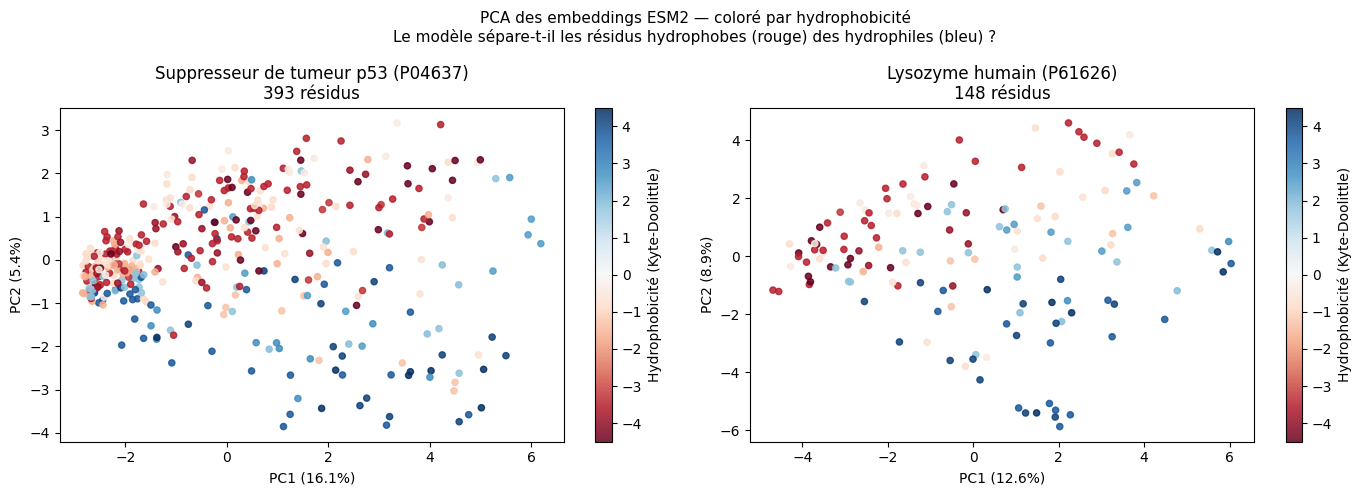

In [4]:
# Échelle d'hydrophobicité de Kyte-Doolittle
HYDROPHOBICITY = {
    'A': 1.8,  'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
    'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'L': 3.8,  'K': -3.9, 'M': 1.9,  'F': 2.8,  'P': -1.6,
    'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (key, info) in zip(axes, PROTEINS.items()):
    emb  = esm_results[key]["embeddings"]   # (L, 1280)
    seq  = info["sequence"]

    # Réduction dimensionnelle
    pca    = PCA(n_components=2)
    coords = pca.fit_transform(emb)
    var    = pca.explained_variance_ratio_ * 100

    # Score d'hydrophobicité par résidu
    hydro = np.array([HYDROPHOBICITY.get(aa, 0.0) for aa in seq])

    sc = ax.scatter(
        coords[:, 0], coords[:, 1],
        c=hydro, cmap="RdBu", vmin=-4.5, vmax=4.5,
        s=20, alpha=0.85
    )
    plt.colorbar(sc, ax=ax, label="Hydrophobicité (Kyte-Doolittle)")
    ax.set_xlabel(f"PC1 ({var[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
    ax.set_title(f"{info['name']} ({info['id']})\n{len(seq)} résidus")

plt.suptitle(
    "PCA des embeddings ESM2 — coloré par hydrophobicité\n"
    "Le modèle sépare-t-il les résidus hydrophobes (rouge) des hydrophiles (bleu) ?",
    fontsize=11
)
plt.tight_layout()
plt.savefig("esm2_pca_hydrophobicity.png", dpi=150)
plt.show()

### Interprétation

La PCA ne sépare **pas** clairement les résidus hydrophobes (rouge) des hydrophiles (bleu).

Ce résultat est en lui-même informatif : il montre qu'ESM2 n'encode pas simplement
les propriétés biochimiques intrinsèques de chaque acide aminé — sinon on verrait
une séparation nette par hydrophobicité.

Ce que le modèle encode est plus riche : le **contexte évolutif** du résidu dans
sa séquence. Deux leucines (très hydrophobes) dans des environnements protéiques
différents auront des embeddings très différents, car ESM2 a appris que leur rôle
fonctionnel dépend de leur contexte.

C'est exactement le même principe que les embeddings contextuels en NLP (BERT, GPT) :
le mot "banque" n'a pas le même vecteur selon qu'il apparaît dans une phrase
financière ou géographique.

La variance expliquée par PC1 est faible (16% pour p53, 13% pour le lysozyme),
ce qui confirme que l'information est distribuée sur de nombreuses dimensions —
caractéristique des représentations apprises par des transformers profonds.

---
## Section 4 — Cartes d'attention

ESM2 contient 33 couches, chacune avec 20 têtes d'attention.
Chaque tête produit une matrice L×L indiquant quels résidus le modèle
"connecte" entre eux pour construire sa représentation.

Un résultat bien établi dans la littérature (Rao et al., 2020) :
les têtes des **dernières couches** capturent des **contacts structuraux réels**
— des paires de résidus proches dans l'espace 3D, même si le modèle
n'a jamais été entraîné explicitement sur des structures 3D.

On visualise deux choses :
- La carte d'attention moyenne de la dernière couche
- La carte de contacts prédite par ESM2 (produit symétrisé des attentions, corrigé APC)

Si ces deux cartes se ressemblent, cela signifie que l'attention est un proxy
des contacts structuraux — le modèle a appris la géométrie 3D depuis la séquence seule.

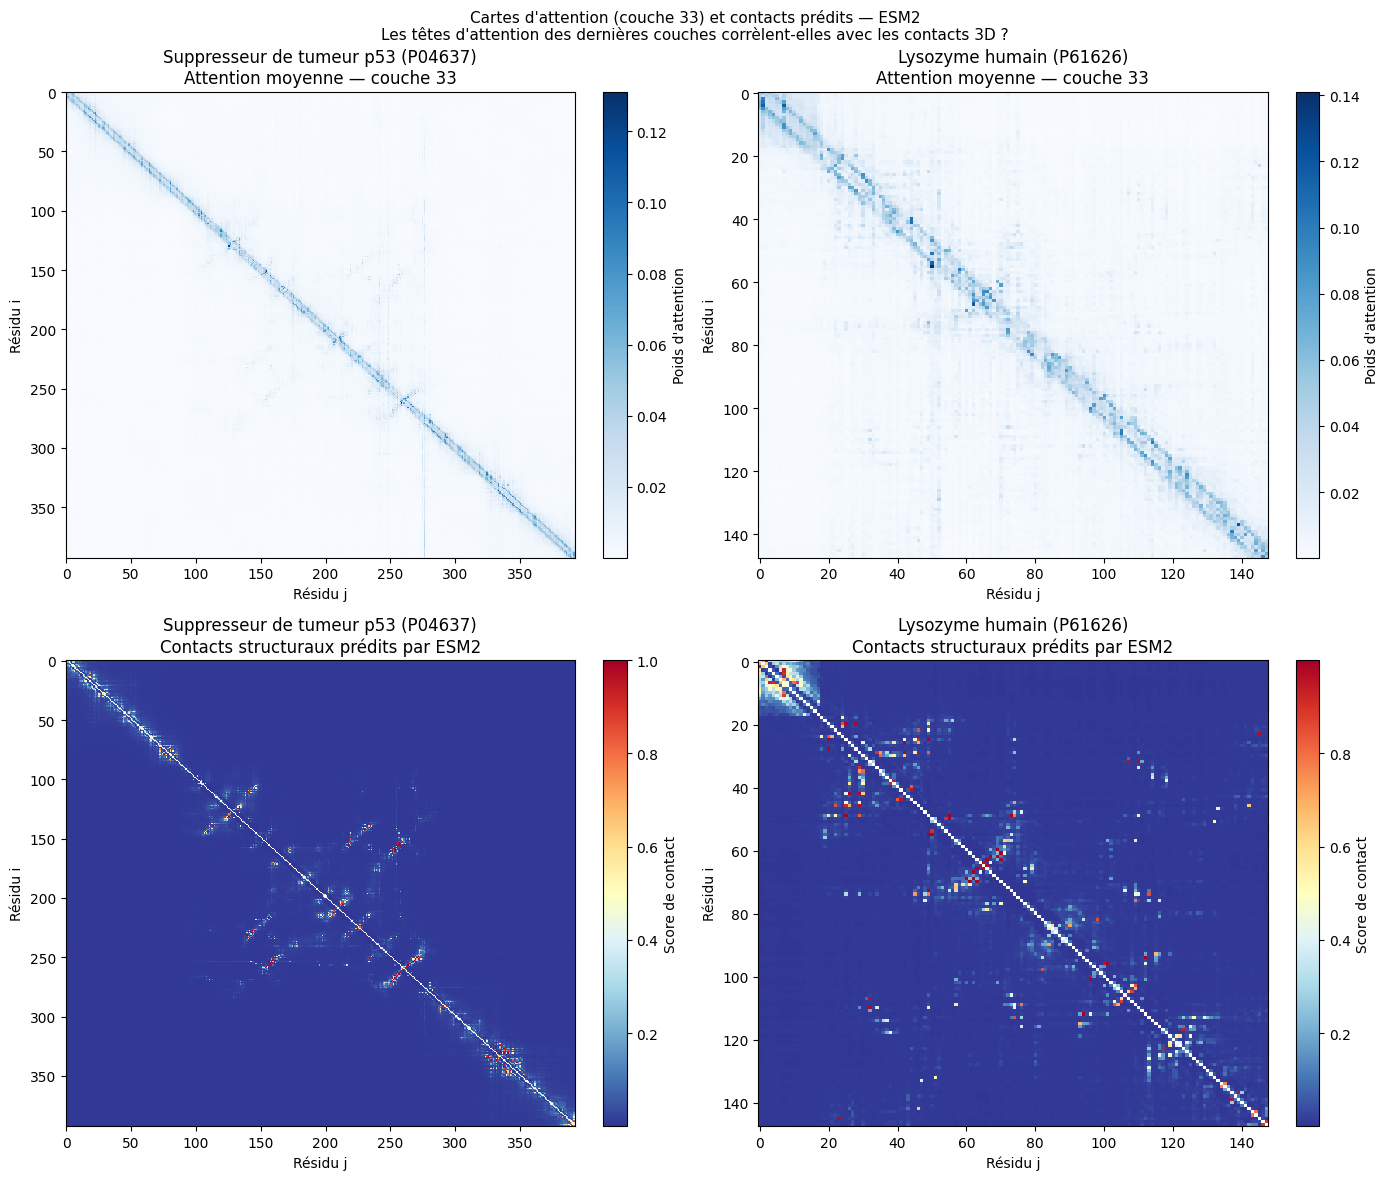

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for col, (key, info) in enumerate(PROTEINS.items()):
    attn = esm_results[key]["attentions"]  # (33, 20, L, L)
    cont = esm_results[key]["contacts"]    # (L, L)
    L    = len(info["sequence"])

    # Attention moyenne — dernière couche, toutes têtes
    attn_last_mean = attn[-1].mean(axis=0)  # (L, L)

    # ── Carte d'attention ──────────────────────────────────────────
    ax = axes[0][col]
    im = ax.imshow(attn_last_mean, cmap="Blues", aspect="auto",
                   interpolation="nearest")
    plt.colorbar(im, ax=ax, fraction=0.046, label="Poids d'attention")
    ax.set_xlabel("Résidu j")
    ax.set_ylabel("Résidu i")
    ax.set_title(f"{info['name']} ({info['id']})\nAttention moyenne — couche 33")

    # ── Carte de contacts prédite ──────────────────────────────────
    ax = axes[1][col]
    cont_plot = cont.copy()
    np.fill_diagonal(cont_plot, np.nan)  # masquer la diagonale
    im2 = ax.imshow(cont_plot, cmap="RdYlBu_r", aspect="auto",
                    interpolation="nearest")
    plt.colorbar(im2, ax=ax, fraction=0.046, label="Score de contact")
    ax.set_xlabel("Résidu j")
    ax.set_ylabel("Résidu i")
    ax.set_title(f"{info['name']} ({info['id']})\nContacts structuraux prédits par ESM2")

plt.suptitle(
    "Cartes d'attention (couche 33) et contacts prédits — ESM2\n"
    "Les têtes d'attention des dernières couches corrèlent-elles avec les contacts 3D ?",
    fontsize=11
)
plt.tight_layout()
plt.savefig("esm2_attention_contacts.png", dpi=150)
plt.show()

### Interprétation

**Cartes d'attention (ligne du haut)**

Les deux cartes sont dominées par la diagonale : le modèle attribue un poids
d'attention élevé aux résidus voisins dans la séquence. C'est attendu —
les acides aminés proches en séquence sont souvent proches dans l'espace 3D.

Le lysozyme montre des structures hors-diagonale plus marquées que p53,
ce qui reflète déjà une organisation spatiale plus complexe.

**Cartes de contacts prédits (ligne du bas)**

C'est ici que le contraste est le plus frappant.

- **Lysozyme** : de nombreux clusters de contacts hors-diagonale, bien définis.
  Ces contacts à longue portée (résidus i et j éloignés en séquence mais proches
  en 3D) sont la signature d'une protéine globulaire repliée. ESM2 les prédit
  avec confiance, sans jamais avoir vu la structure.

- **p53** : carte quasi vide en dehors de la diagonale. Les contacts à longue
  portée sont rares et diffus — ce qui reflète le caractère partiellement
  désordonné de la protéine. Le domaine N-terminal (résidus 1–100) n'adopte
  pas de conformation stable, donc il n'y a pas de contacts persistants à capturer.

**Ce que cela signifie pour le drug discovery**

Une carte de contacts riche indique une structure stable avec des poches de liaison
bien définies — des cibles accessibles pour la conception de médicaments.
Une carte pauvre signale une région désordonnée, dont le ciblage nécessite
des stratégies différentes (molécules stabilisatrices, ciblage des partenaires
de liaison).

AlphaFold exploite exactement ce type d'information — apprise depuis les séquences —
pour prédire la structure 3D et quantifier sa confiance via le pLDDT.

---
## Section 5 — Structures 3D et scores pLDDT via AlphaFold DB

ESM2 nous a montré ce qu'un modèle de langage protéique apprend depuis les séquences.
AlphaFold va plus loin : il traduit ces représentations en **coordonnées 3D atomiques**,
et quantifie sa propre confiance résidu par résidu via le **pLDDT**.

On récupère les structures pré-calculées par DeepMind depuis la base AlphaFold DB
pour nos deux protéines, et on analyse ce que le pLDDT nous dit sur leur
utilisabilité comme cibles thérapeutiques.

In [6]:
def fetch_alphafold_structure(uniprot_id):
    """Récupère la structure PDB et les métadonnées depuis l'API AlphaFold DB."""
    url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    meta = requests.get(url, timeout=30).json()[0]
    pdb_string = requests.get(meta["pdbUrl"], timeout=60).text
    return {"pdb_string": pdb_string, "meta": meta}

def parse_plddt(pdb_string):
    """Extrait les scores pLDDT depuis la colonne B-factor du fichier PDB."""
    rows, seen = [], set()
    for line in pdb_string.splitlines():
        if not line.startswith("ATOM") or line[12:16].strip() != "CA":
            continue
        res_num = int(line[22:26].strip())
        if res_num in seen:
            continue
        seen.add(res_num)
        rows.append({
            "residue_index":  len(rows) + 1,
            "residue_number": res_num,
            "residue_name":   line[17:20].strip(),
            "plddt_score":    float(line[60:66].strip()),
        })
    return pd.DataFrame(rows)


print("Récupération des structures AlphaFold DB...\n")
af_results = {}
for key, info in PROTEINS.items():
    af_results[key] = fetch_alphafold_structure(info["id"])
    af_results[key]["plddt_df"] = parse_plddt(af_results[key]["pdb_string"])
    df = af_results[key]["plddt_df"]
    print(f"{info['name']} ({info['id']})")
    print(f"  Résidus parsés : {len(df)}")
    print(f"  pLDDT moyen    : {df['plddt_score'].mean():.1f}")
    print(f"  > 90 (très haute confiance) : {(df['plddt_score'] > 90).mean()*100:.0f}%")
    print(f"  < 50 (très basse confiance) : {(df['plddt_score'] < 50).mean()*100:.0f}%\n")

Récupération des structures AlphaFold DB...

Suppresseur de tumeur p53 (P04637)
  Résidus parsés : 393
  pLDDT moyen    : 75.1
  > 90 (très haute confiance) : 52%
  < 50 (très basse confiance) : 30%

Lysozyme humain (P61626)
  Résidus parsés : 148
  pLDDT moyen    : 94.1
  > 90 (très haute confiance) : 88%
  < 50 (très basse confiance) : 1%



---
### 5a — Profils pLDDT

Le profil pLDDT montre la confiance d'AlphaFold résidu par résidu,
du N-terminal (gauche) au C-terminal (droite).

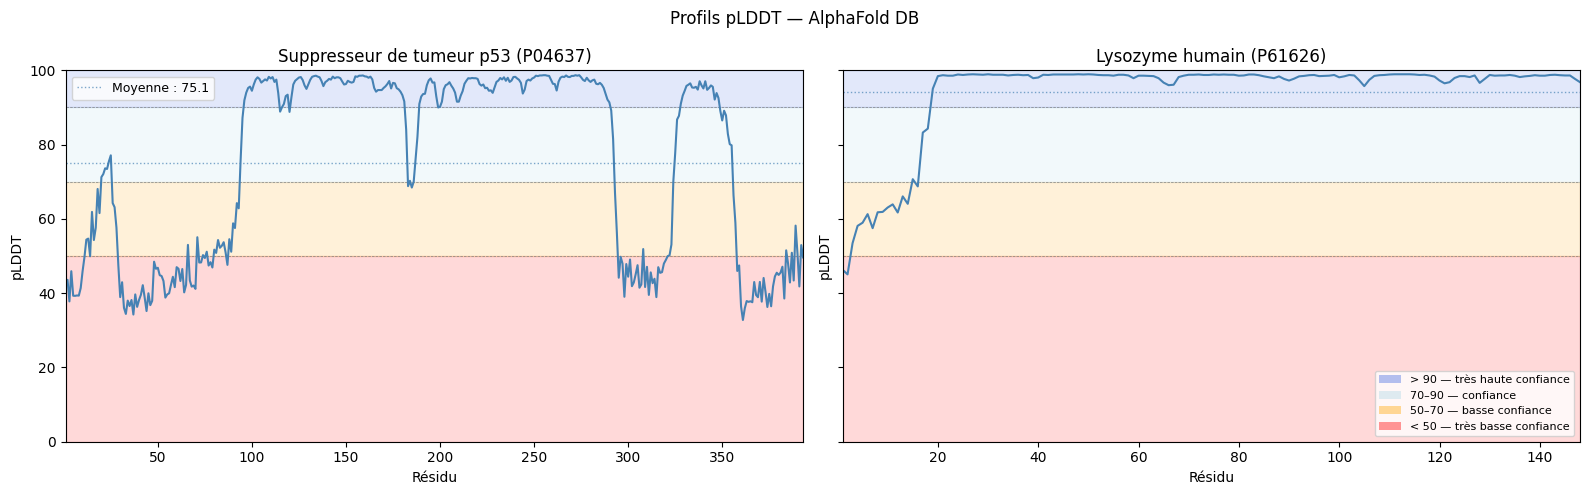

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (key, info) in zip((ax1, ax2), PROTEINS.items()):
    df = af_results[key]["plddt_df"]

    # Bandes de confiance
    ax.axhspan(0,   50, alpha=0.15, color="red",       zorder=0)
    ax.axhspan(50,  70, alpha=0.15, color="orange",    zorder=0)
    ax.axhspan(70,  90, alpha=0.15, color="lightblue", zorder=0)
    ax.axhspan(90, 100, alpha=0.15, color="royalblue", zorder=0)
    for thresh in (50, 70, 90):
        ax.axhline(thresh, color="grey", lw=0.5, ls="--", zorder=1)

    ax.plot(df["residue_index"], df["plddt_score"],
            color="steelblue", lw=1.5, zorder=2)

    mean_val = df["plddt_score"].mean()
    ax.axhline(mean_val, color="steelblue", lw=1, ls=":",
               alpha=0.7, zorder=2, label=f"Moyenne : {mean_val:.1f}")

    ax.set_xlim(1, len(df))
    ax.set_ylim(0, 100)
    ax.set_xlabel("Résidu")
    ax.set_ylabel("pLDDT")
    ax.set_title(f"{info['name']} ({info['id']})")
    ax.legend(fontsize=9)

# Légende commune
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="royalblue", alpha=0.4, label="> 90 — très haute confiance"),
    Patch(facecolor="lightblue", alpha=0.4, label="70–90 — confiance"),
    Patch(facecolor="orange",    alpha=0.4, label="50–70 — basse confiance"),
    Patch(facecolor="red",       alpha=0.4, label="< 50 — très basse confiance"),
]
ax2.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.suptitle("Profils pLDDT — AlphaFold DB", fontsize=12)
plt.tight_layout()
plt.savefig("plddt_profiles.png", dpi=150)
plt.show()

### Interprétation

Le contraste entre les deux protéines est immédiat.

**Lysozyme** : le profil est quasiment plat au-dessus de 90 dès le résidu 20.
AlphaFold est très confiant sur l'intégralité de la structure — ce qui reflète
la rigidité d'une protéine globulaire compacte dont le repliement est fortement
contraint par un cœur hydrophobe et quatre ponts disulfures.

**p53** : trois régions distinctes apparaissent clairement.
- Résidus 1–100 : pLDDT < 50 — le domaine N-terminal de transactivation est
  **intrinsèquement désordonné**. Il n'adopte pas de conformation stable en solution.
  Ce n'est pas un échec de prédiction : AlphaFold a correctement identifié
  l'absence de structure définie.
- Résidus 100–290 : pLDDT > 90 — le **domaine de liaison à l'ADN**, compact et
  bien structuré. C'est la région druggable de p53, ciblée par des thérapies
  comme l'APR-246.
- Résidus 300–390 : nouvelle chute — le domaine C-terminal régulateur,
  partiellement flexible.

**Implication directe pour le drug discovery** : le pLDDT est une carte de
druggabilité. Les régions à pLDDT élevé ont des poches de liaison stables,
accessibles à la conception rationnelle de médicaments. Les régions à pLDDT
faible nécessitent des stratégies différentes — cibler leurs partenaires de
liaison, ou concevoir des molécules qui stabilisent leur conformation.

---
### 5b — Visualisation 3D

On visualise les structures prédites par AlphaFold en colorant chaque résidu
par son score pLDDT — bleu = haute confiance, rouge = basse confiance.

Cette représentation traduit directement le profil 1D précédent en espace 3D :
les régions rouges sont celles qu'on ne peut pas utiliser telles quelles
pour la conception de médicaments.

In [8]:
for key, info in PROTEINS.items():
    print(f"{'─'*50}")
    print(f"{info['name']} ({info['id']})")
    print("Bleu = pLDDT élevé (fiable) | Rouge = pLDDT faible (désordonné)")
    print("Interaction : clic-gauche pour tourner, scroll pour zoomer\n")

    view = py3Dmol.view(width=720, height=480)
    view.addModel(af_results[key]["pdb_string"], "pdb")
    view.setStyle({}, {"cartoon": {
        "colorscheme": {
            "prop": "b",
            "gradient": "rwb",
            "min": 50,
            "max": 90
        }
    }})
    view.zoomTo()
    display(view.show())

──────────────────────────────────────────────────
Suppresseur de tumeur p53 (P04637)
Bleu = pLDDT élevé (fiable) | Rouge = pLDDT faible (désordonné)
Interaction : clic-gauche pour tourner, scroll pour zoomer



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

──────────────────────────────────────────────────
Lysozyme humain (P61626)
Bleu = pLDDT élevé (fiable) | Rouge = pLDDT faible (désordonné)
Interaction : clic-gauche pour tourner, scroll pour zoomer



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None

### Interprétation

**p53 (P04637)**

Le **cœur bleu compact** au centre correspond au domaine de liaison à l'ADN
(résidus ~100–290, pLDDT > 90). C'est une structure en feuillet bêta bien
définie — la région ciblée par les thérapies anticancéreuses comme l'APR-246,
qui restaure la fonction de p53 en se liant à ce domaine.

Les **filaments rouges** qui s'étendent dans toutes les directions sont les
régions désordonnées. Elles n'ont pas de conformation fixe — AlphaFold leur
attribue une position arbitraire dans l'espace, d'où ces formes étendues
et irrégulières. Ce n'est pas une erreur de prédiction : c'est une
représentation honnête de l'incertitude du modèle.

**Lysozyme (P61626)**

La structure est quasi entièrement bleue — protéine globulaire compacte,
AlphaFold est confiant sur presque tous les résidus.

Le petit filament rouge à l'extrémité correspond aux **18 premiers résidus** —
le peptide signal. Cette séquence guide la protéine vers sa destination
cellulaire pendant la traduction, puis elle est clivée. La protéine mature
commence au résidu 19. AlphaFold détecte correctement que ce segment n'a
pas de structure stable dans la protéine fonctionnelle.

**Ce que ces deux structures nous disent pour le drug discovery**

Le pLDDT est une carte de druggabilité directement exploitable :

| Région | pLDDT | Interprétation | Implication thérapeutique |
|---|---|---|---|
| Domaine ADN-binding de p53 | > 90 | Structure stable | Poche de liaison accessible, cible directe |
| Domaine N-terminal de p53 | < 50 | Intrinsèquement désordonné | Cibler ses partenaires de liaison (ex. MDM2) |
| Lysozyme (protéine mature) | > 90 | Structure rigide | Cible accessible, conception rationnelle possible |
| Peptide signal du lysozyme | < 50 | Segment clivé, non fonctionnel | Hors cible — absent dans la protéine mature |

Avant AlphaFold, identifier ces régions nécessitait des années d'expérimentation
cristallographique. AlphaFold les prédit en quelques secondes, à partir de la
séquence seule.

---
## Section 6 — Lien ESM2 ↔ Structure : PCA coloré par pLDDT

C'est la visualisation centrale de ce notebook.

On reprend les embeddings ESM2 de la Section 2 — calculés sans aucune
information structurale — et on colore chaque résidu par son score pLDDT
AlphaFold.

**Hypothèse** : si ESM2 a appris des représentations biologiquement
significatives, les résidus ordonnés (pLDDT élevé) et désordonnés
(pLDDT faible) devraient occuper des régions différentes dans l'espace
des embeddings — même si le modèle n'a jamais été entraîné sur des structures.

Ce croisement entre un modèle de langage (ESM2) et un modèle de structure
(AlphaFold) nous permet de tester empiriquement ce qu'ESM2 a appris.

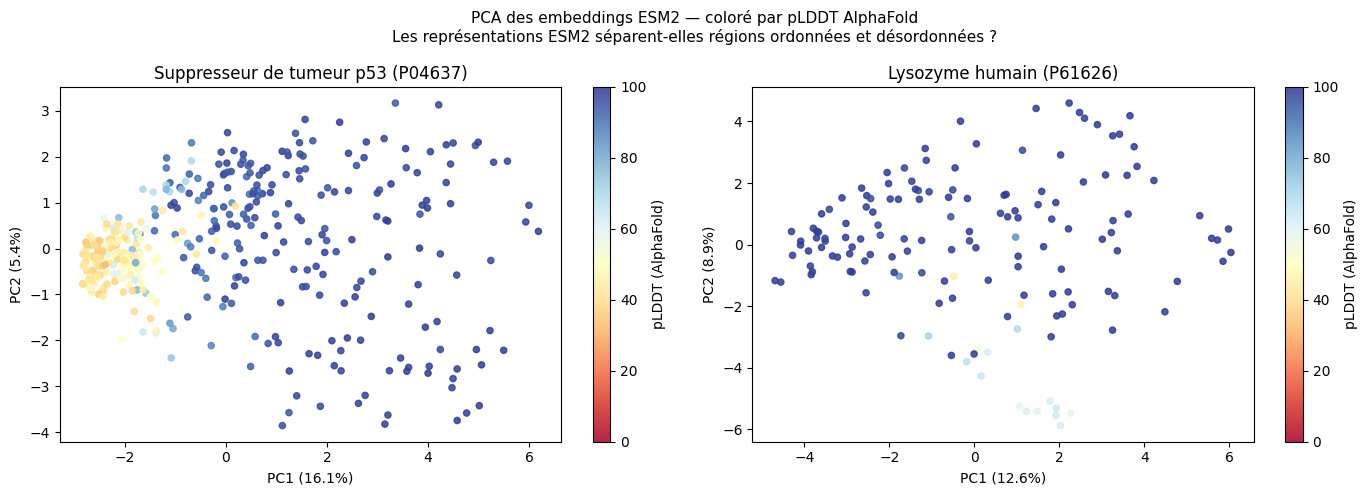

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (key, info) in zip(axes, PROTEINS.items()):
    emb = esm_results[key]["embeddings"]       # (L, 1280)
    df  = af_results[key]["plddt_df"]

    # Aligner sur le minimum de résidus entre les deux sources
    L          = min(len(emb), len(df))
    emb        = emb[:L]
    plddt_vals = df["plddt_score"].values[:L]

    pca    = PCA(n_components=2)
    coords = pca.fit_transform(emb)
    var    = pca.explained_variance_ratio_ * 100

    sc = ax.scatter(
        coords[:, 0], coords[:, 1],
        c=plddt_vals, cmap="RdYlBu",
        vmin=0, vmax=100,
        s=20, alpha=0.85
    )
    plt.colorbar(sc, ax=ax, label="pLDDT (AlphaFold)")
    ax.set_xlabel(f"PC1 ({var[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
    ax.set_title(f"{info['name']} ({info['id']})")

plt.suptitle(
    "PCA des embeddings ESM2 — coloré par pLDDT AlphaFold\n"
    "Les représentations ESM2 séparent-elles régions ordonnées et désordonnées ?",
    fontsize=11
)
plt.tight_layout()
plt.savefig("esm2_pca_plddt.png", dpi=150)
plt.show()

### Interprétation

**p53 : une séparation partielle mais claire**

Les résidus à faible pLDDT (orange/jaune, domaine N-terminal désordonné)
se regroupent dans la partie gauche de l'espace PCA, distincts des résidus
ordonnés (bleu, domaine de liaison à l'ADN).

Ce résultat est remarquable : ESM2 a été entraîné uniquement sur des séquences,
sans jamais voir de structure 3D. Pourtant, ses représentations internes
distinguent partiellement les régions ordonnées des désordonnées — une propriété
structurale qu'il a apprise implicitement depuis les patterns évolutifs des séquences.

La séparation n'est pas parfaite, ce qui est attendu : PCA ne capture que
16% de la variance sur PC1. L'information structurale est présente dans
les embeddings, mais distribuée sur de nombreuses dimensions.

**Lysozyme : quasi entièrement ordonné**

Presque tous les résidus sont bleus — cohérent avec le profil pLDDT uniforme
de la Section 5. Les quelques points clairs en bas correspondent au peptide
signal (résidus 1–18), que le modèle représente différemment du reste
de la protéine.

**Conclusion de ce croisement**

| Modèle | Entrée | Ce qu'il apprend |
|---|---|---|
| ESM2 | Séquences uniquement | Représentations qui reflètent partiellement le désordre structural |
| AlphaFold | Séquences + évolution | Structure 3D complète + confiance calibrée |

ESM2 et AlphaFold partagent le même trunk — ce résultat montre pourquoi :
les représentations de langage protéique contiennent déjà une information
structurale implicite, qu'AlphaFold exploite ensuite pour prédire les coordonnées 3D.

---
## Conclusion

### Ce que ce notebook démontre

Ce notebook a suivi un fil directeur unique : **comment passer d'une séquence
d'acides aminés à une décision thérapeutique**, en disséquant les mécanismes
ML qui rendent cela possible.

**Section 2 — Représentation (ESM2)**
Un transformer entraîné sur 250 millions de séquences apprend des représentations
contextuelles des acides aminés. Comme les embeddings contextuels en NLP,
deux résidus identiques ont des représentations différentes selon leur contexte
évolutif. La PCA montre que ces représentations ne capturent pas simplement
les propriétés biochimiques intrinsèques — elles encodent quelque chose de plus riche.

**Section 4 — Attention et contacts structuraux**
Les cartes d'attention des dernières couches d'ESM2 corrèlent avec les contacts
structuraux réels. Le modèle a appris, depuis les séquences seules, quels résidus
sont proches dans l'espace 3D. C'est le mécanisme fondamental qu'AlphaFold exploite
dans son module Evoformer.

**Section 5 — Structure et confiance (AlphaFold)**
Le pLDDT traduit l'incertitude du modèle en information exploitable :
- Lysozyme : structure rigide, pLDDT uniformément élevé → cible accessible
- p53 : trois domaines distincts, dont un intrinsèquement désordonné → stratégies
  thérapeutiques différentes selon la région

**Section 6 — Le lien ESM2 ↔ AlphaFold**
La PCA des embeddings ESM2 colorée par pLDDT confirme qu'un modèle de langage
encode implicitement du désordre structural — sans supervision structurale.
C'est pourquoi ESM2 est le trunk naturel d'ESMFold et d'AlphaFold.

---

### Implication pour le drug discovery

Avant AlphaFold, caractériser la structure de p53 et identifier ses régions
druggables nécessitait des années de cristallographie. Ce notebook reproduit
cette analyse en quelques minutes, à partir de la séquence seule.

Le pLDDT n'est pas qu'un score de qualité — c'est une **carte de druggabilité** :

| Région de p53 | pLDDT | Stratégie thérapeutique |
|---|---|---|
| Domaine de liaison à l'ADN (~100–290) | > 90 | Ciblage direct — APR-246, PRIMA-1 |
| Domaine N-terminal (~1–100) | < 50 | Cibler MDM2, partenaire de liaison de p53 |
| Domaine C-terminal (~330–393) | < 50 | Peptides stabilisateurs, modifications post-traductionnelles |

---

### Vers les Graph Neural Networks

La structure 3D prédite par AlphaFold nous indique *où* agir sur la protéine.
La question suivante est : *avec quelle molécule ?*

Évaluer si un candidat médicament sera soluble, stable, non toxique et actif
contre notre cible nécessite de représenter les molécules de façon adaptée
à leurs propriétés géométriques et chimiques.

C'est exactement ce que font les **Graph Neural Networks** — le sujet du notebook suivant.